# Project 1 : Monte Carlo Simulation of the One-Dimensional Ising Model

## Context and Motivation
- The Ising model is one of the pillars of statistical mechanics, providing a fundamental framework for studying phase transitions and magnetic systems.
- While the one-dimensional (1D) version of this model does not exhibit a phase transition at non-zero temperatures, it serves as an essential pedagogical tool and a benchmark for numerical methods.
- This project focuses on simulating a chain of $N$ spins interacting via the exchange energy $J$ in the absence of an external magnetic field.

## Theoretical Background
- In the 1D Ising model, the energy of a configuration is determined by the interaction between nearest neighbors.
- One of the key objectives of this study is to compare numerical results obtained via the Metropolis algorithm with exact analytical solutions. Specifically, we will verify the internal energy $E(T)$ against the theoretical formula:
 $$E(T) = -N \tanh \beta J \quad \text{with} \quad \beta = \frac{1}{k_B T} $$

## Objectives of the Project
The primary goal of this work is to implement a Monte Carlo simulation using the heat bath equilibrium method to explore the thermodynamic properties of the system. The project is structured around the following key tasks:
- **Algorithm Implementation:** Developing a robust simulation using periodic boundary conditions and the Metropolis algorithm.
- **Thermodynamic Observables:** Computing energy $\langle E \rangle$, magnetisation $\langle M \rangle$, specific heat $C$, and magnetic susceptibility $\chi$ as functions of temperature $T$.


---

# Python

## import

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Constants

Our systeme is the Ising model 1D with periodic boundary condition :
$$H = J \sum_j \sigma_j \sigma_{j+1} + h \sum_j \sigma_j \qquad \text{with} \quad \sigma_j = \pm 1, \quad \sigma_{N+1} = \sigma_1$$
apply on a $N$ spin chain.

So we need to take :
- $N = 100$,
- $J = 1$,
- $h = 0$ (no magnetic field),
- $k_B = 1$ for less compution time,
- Range of temperature for the simulation : $[0.5, 10]$ with step of $0.1$.


In [2]:
# Constante Physique
global N, KB, N_thermalisation, J, h

N = 100 # Nombre de spins dans la chaine

KB = 1. # Constante de Boltzmann
J = 1. # Constante d'intéraction avec le proche voisin
h = 0. # Constante Magnétisme = 0 cause of an absence of an external magnetic field

Ti = 10. # Température initial du système
Tf = 0.5 # Température final du système

# Constant numérique
dT = 0.1 # pas entre chaque temperature que notre systeme va atteindre
T = np.linspace(Tf, Ti, int((Ti-Tf)/dT) + 1) # liste de température par les quel le systeme va passser

Nt = 1000 # Nombre de pas de temps a chaque étape
N_thermalisation = 4 * Nt # Nombre de pas de temps pour thérmaliser notre système
N_skip = 5 # pour eviter la corrélation entre les grandeur mesuré
N_runs = 10 # nombre de fois que l'on fait la simulation de monte carlo pour obtenir des meilleurs moyennes et barre d'erreur

---

## Monte Carlo method


### Metropolis step for the Ising model

1. **Selection:** Pick a random spin site $i$ from the lattice of size $N$.
2. **Trial:** Propose a spin flip: $s_i \rightarrow -s_i$.
3. **Energy Calculation:** Compute the energy change $\Delta E$ associated with this flip.
4. **Acceptance Criterion:**
   - If $\Delta E \leq 0$: The change is **accepted**.
   - If $\Delta E > 0$: The change is accepted only with a probability $P = e^{-\beta \Delta E}$, the **boltzmann factor**.
   - Otherwise, the spin remains unchanged.

### Energy change :

- $\Delta E = 2J s_i (s_{i-1} + s_{i+1})$

### Thermalization

Before starting to measure physical observables, the system must undergo a **thermalization** phase.

The initial state is usually arbitrary and does not belong to the Boltzmann distribution. Measurements taken too early would be biased by this starting point.
So we wait for the system's total energy to fluctuate around a stable mean value. Once this "steady state" is reached, we can assume the samples are valid representatives of the canonical ensemble. Because measurements are only averaged **after** thermalization to ensure that the computed means $\langle E \rangle$ or $\langle M \rangle$ reflect the true physics of the model rather than the simulation's transient behavior.

In [3]:
def boltzmann_factor(dE : float, T : float) -> float:
  return np.exp(-dE/(T*KB))

def compute_dE(spins : np.ndarray, i : int) -> float:
  return 2*J*spins[i]*(spins[(i-1)%N] + spins[(i+1)%N]) # modulo % for PBC

def evolution(spins : np.ndarray, T : float) -> int :
  i = np.random.randint(N)
  dE = compute_dE(spins, i)
  acceptation = 0
  if dE <= 0 or boltzmann_factor(dE,T) > np.random.rand() :
    spins[i] *= -1
    acceptation = 1
  return acceptation

def monte_carlo_step(spins : np.ndarray, T:float):
    accept = 0
    for _ in range(N): # pour que le nombre de step corresponde bien au nombre de MCS
        accept += evolution(spins, T)
    return accept / N

def thermalisation(spins : np.ndarray, T : float) -> None :
  for _ in range(N_thermalisation) :
    monte_carlo_step(spins, T)
  return

---

## Computation quantities functions

To monitor the system's evolution in Monte Carlo's method, we track the average of this quantities :

### Hamiltonian of the Ising model in 1D :

- $H = - J \Sigma_{i=1}^{N} s_is_{i+1} + h \Sigma_{i=1}^{N} s_i \quad s_i = \pm 1 \quad \text{with PBC :} \quad s_{N+1} = s_{1} $

### Magnetisation :

- $ M = \frac{\Sigma_{i=1}^{N} s_i}{N} $

### Suceptibility :

- $\chi = N \beta(\langle m^2\rangle-\langle m\rangle^2)$

### Specific Heat :

- $ C_v = \frac{\beta^2}{N}(\langle E^2\rangle-\langle E\rangle^2) $



In [4]:
def compute_E(spins : np.ndarray) -> float:
  return -J*( np.sum(spins[:-1]*spins[1:]) + spins[0]*spins[-1] ) - h*np.sum(spins) # le terme spins[0]*spins[-1] pour la PBC

def compute_m(spins : np.ndarray) -> float:
  return np.mean(spins)

def compute_suceptibility(m : np.array, T : float) -> float:
  return N * np.var(m) / (T*KB)

def compute_specific_heat(E : np.array, T : float) -> float:
  return np.var(E)/(N*T*T*KB*KB)

global quantities
quantities = ["Energy", "magnetization", "Suceptibility", "Specific heat Cv", "Acceptation"]

def init_list_measurement() -> dict :
    dict = {}
    for quantitie in quantities :
        dict[quantitie] = []
    return dict

## Theoric quantities

We need to compare our result with the theorical result for interpretation.

### Theoric Energy :

- $E(T) = -N \tanh \beta J \quad $ for ($h=0$).

### Theoric Magnetisation :

- $m(T, h) = \frac{\sinh(\beta h)}{\sqrt{\sinh^2(\beta h) + e^{-4\beta J}}}$

### Theoric Suceptibility :

- $\chi(T, h) = \beta \frac{e^{-4\beta J} \cosh(\beta h)}{\left[ \sinh^2(\beta h) + e^{-4\beta J} \right]^{3/2}}$

### Theoric Specific Heat :

- $c_v(T) = k_B \left( \frac{J}{k_B T} \right)^2 \frac{1}{\cosh^2\left( \frac{J}{k_B T} \right)} \quad $ for ($h=0$).

In [5]:
def E_theoric(T : np.array) -> np.array:
    beta = 1.0 / (KB * T)
    return -N * np.tanh(beta * J)

def m_theoric(T : np.array) -> np.array:
    beta = 1.0 / (KB * T)
    num = np.sinh(beta * h)
    denom = np.sqrt(np.sinh(beta * h)**2 + np.exp(-4 * beta * J))
    return num / denom

def compute_suceptibility_theoric(T : np.array) -> np.array:
    beta = 1.0 / (KB * T)
    num = beta * np.exp(-4 * beta * J) * np.cosh(beta * h)
    denom = (np.sinh(beta * h)**2 + np.exp(-4 * beta * J))**(1.5)
    return num / denom

def compute_specific_heat_theoric(T : np.array) -> np.array:
    beta = 1.0 / (KB * T)
    return KB * (beta * J)**2 * (1.0 / np.cosh(beta * J)**2)

In [6]:
# theorical mesure pour comparer nos resultats
theoric_result = {}
theoric_result["Energy"] = E_theoric(T)
theoric_result["magnetization"] = m_theoric(T)
theoric_result["Suceptibility"] = compute_suceptibility_theoric(T)
theoric_result["Specific heat Cv"] = compute_specific_heat_theoric(T)

---

## Simulation of physical quantities for a temperature T

In [7]:
def simulation(T : float, Nt : int, N_skip : int) :
    spins = np.random.choice([-1, 1], size=N) # Notre système aléatoire

    result = init_list_measurement() # list of measurement

    thermalisation(spins, T)

    m_temp, E_temp, acceptation_temp = [], [], [] # reinitialisation des listes temporaires
    for _ in range(Nt//N_skip) :
        for _ in range(N_skip): # pour avoir moin de corrélation entre les mesures
            monte_carlo_step(spins, T)

        acceptation_temp.append(monte_carlo_step(spins, T)) # change un s_i -> - s_i

        # Calcul des magnétisations et énergies
        m_temp.append(compute_m(spins))
        E_temp.append(compute_E(spins))

    # Stock et calculs des valeurs
    result["Energy"].append(np.mean(E_temp))
    result["magnetization"].append(np.mean(m_temp))
    result["Suceptibility"].append(compute_suceptibility(np.array(m_temp), T))
    result["Specific heat Cv"].append(compute_specific_heat(np.array(E_temp), T))
    result["Acceptation"].append(np.mean(acceptation_temp))

    return spins, result

## Statistical Analysis and Error Estimation

In a Monte Carlo simulation of the **1D Ising Model**, we estimate physical observables by averaging over many stochastic configurations. However, a single simulation run only provides a "sample mean," which is subject to statistical fluctuations.

By running $K$ independent simulations (or blocks) at the same temperature $T$, we obtain a distribution of measurements $\{m_1, m_2, ..., m_K\}$. The average of these values is a much more robust estimator of the true thermodynamic value than a single run.
It allows us to calculate the **Standard Error of the Mean (SEM)**. This tells us how much our final result is expected to vary if we were to repeat the entire experiment.

The error bar ($\Delta m$) for a set of $K$ measurements is calculated as:
$$\Delta m = \frac{\sigma}{\sqrt{K}}$$
where $\sigma$ is the standard deviation of the block means.

In [8]:
def compute_stats(list : list):
    K = len(list)
    if K < 2:
        return list[0], 0  # Impossible de calculer une erreur avec un seul point

    list_moy = np.mean(list)

    # Écart-type des blocs
    sigma_k = np.std(list) # ddof=1 pour l'échantillonnage (n-1)

    # Erreur standard (la taille de ta barre d'erreur)
    list_error = sigma_k / np.sqrt(K)

    return list_moy, list_error

## spin chain's visualisation

In [9]:
def plot_chain(spins : np.ndarray, T:float) :
    plt.title(f"For T={round(T, 2)}")
    plt.imshow(spins.reshape(1,len(spins)), cmap="gray")
    plt.show()

## Final simulation

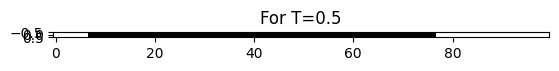

T=0.5 complete
T=0.6 complete
T=0.7 complete
T=0.8 complete
T=0.9 complete
T=1.0 complete
T=1.1 complete
T=1.2 complete
T=1.3 complete
T=1.4 complete


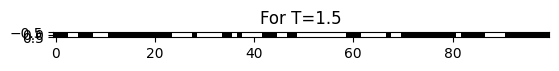

T=1.5 complete
T=1.6 complete
T=1.7 complete
T=1.8 complete
T=1.9 complete
T=2.0 complete
T=2.1 complete
T=2.2 complete
T=2.3 complete
T=2.4 complete


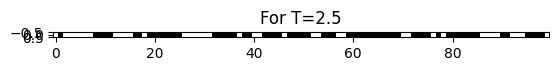

T=2.5 complete
T=2.6 complete
T=2.7 complete
T=2.8 complete
T=2.9 complete
T=3.0 complete
T=3.1 complete
T=3.2 complete
T=3.3 complete
T=3.4 complete


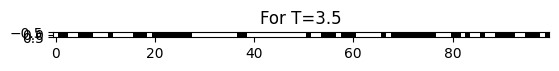

T=3.5 complete
T=3.6 complete
T=3.7 complete
T=3.8 complete
T=3.9 complete
T=4.0 complete
T=4.1 complete
T=4.2 complete
T=4.3 complete
T=4.4 complete


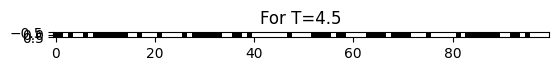

T=4.5 complete
T=4.6 complete
T=4.7 complete
T=4.8 complete
T=4.9 complete
T=5.0 complete
T=5.1 complete
T=5.2 complete
T=5.3 complete
T=5.4 complete


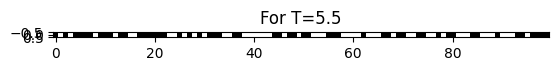

T=5.5 complete
T=5.6 complete
T=5.7 complete
T=5.8 complete
T=5.9 complete
T=6.0 complete
T=6.1 complete
T=6.2 complete
T=6.3 complete
T=6.4 complete


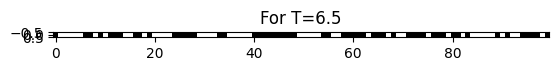

T=6.5 complete
T=6.6 complete
T=6.7 complete
T=6.8 complete
T=6.9 complete
T=7.0 complete
T=7.1 complete
T=7.2 complete
T=7.3 complete
T=7.4 complete


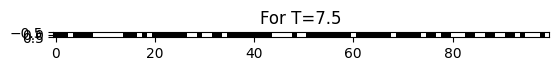

T=7.5 complete
T=7.6 complete
T=7.7 complete
T=7.8 complete
T=7.9 complete
T=8.0 complete
T=8.1 complete
T=8.2 complete
T=8.3 complete
T=8.4 complete


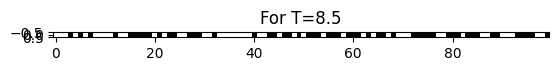

T=8.5 complete
T=8.6 complete
T=8.7 complete
T=8.8 complete
T=8.9 complete
T=9.0 complete
T=9.1 complete
T=9.2 complete
T=9.3 complete
T=9.4 complete


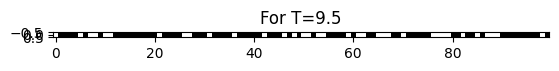

T=9.5 complete
T=9.6 complete
T=9.7 complete
T=9.8 complete
T=9.9 complete
T=10.0 complete


In [10]:
def simulations(T : list, Nt : int, N_skip : int, N_runs : int) :
    result = init_list_measurement() # list of measurement
    result_error = init_list_measurement() # list of error

    for j, Tj in enumerate(T) :
        result_run = init_list_measurement()

        for _ in range(N_runs) :
            spins, result_temp = simulation(Tj, Nt, N_skip)

            for quantitie in quantities :
                result_run[quantitie].append(result_temp[quantitie])

        # On calcule la moyenne et l'erreur pour cette température Tj
        for quantitie in quantities :
            result_average_Tj, result_error_Tj = compute_stats(result_run[quantitie])

            result[quantitie].append(np.mean(result_average_Tj))
            result_error[quantitie].append(np.mean(result_error_Tj))

        if j%10 == 0 :
            plot_chain(spins, Tj)

        print(f"T={Tj.round(2)} complete")

    return result, result_error

result, result_error = simulations(T, Nt, N_skip, N_runs)

## Plot Result

Energy Average error : 0.17561153307016084
magnetization Average error : 0.006765625
Suceptibility Average error : 1.0315912224218686
Specific heat Cv Average error : 0.0026004256017193557


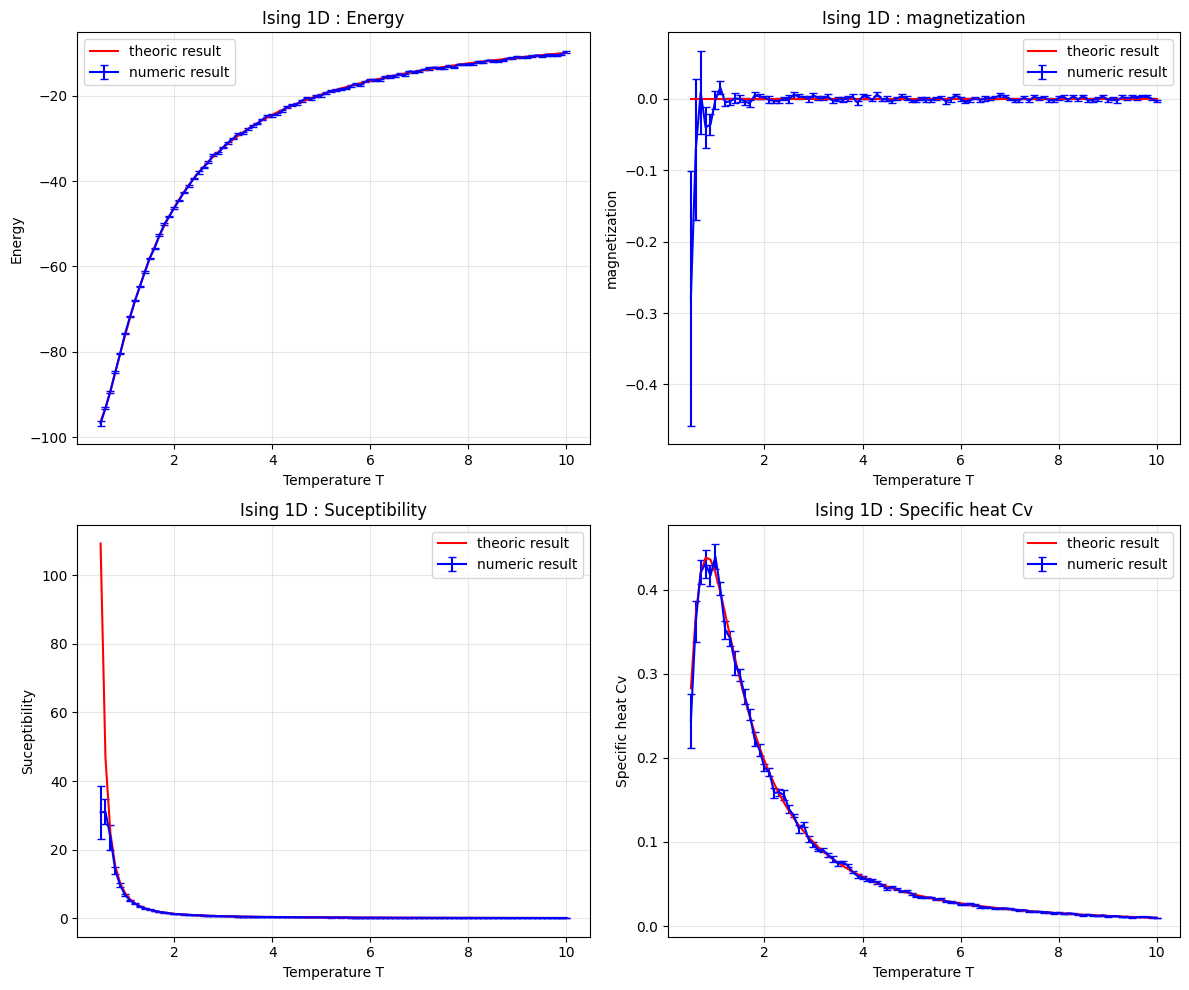

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, quantitie in enumerate(["Energy", "magnetization", "Suceptibility", "Specific heat Cv"]):
    numeric_value = result[quantitie]
    value_error = result_error[quantitie]
    theoric_value = theoric_result[quantitie]

    ax = axes[i]

    # Plot
    ax.errorbar(T, numeric_value, yerr=value_error, capsize=3, color='blue',
                linestyle='-', label='numeric result')
    ax.plot(T, theoric_value, color='red', label='theoric result')

    ax.set_xlabel('Temperature T')
    ax.set_ylabel(quantitie)
    ax.set_title(f"Ising 1D : {quantitie}")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Average Error
    quantitie_error = np.mean(np.abs(numeric_value - theoric_value))
    print(f"{quantitie} Average error : {quantitie_error}")

plt.tight_layout()
plt.show()

## Acceptation plot

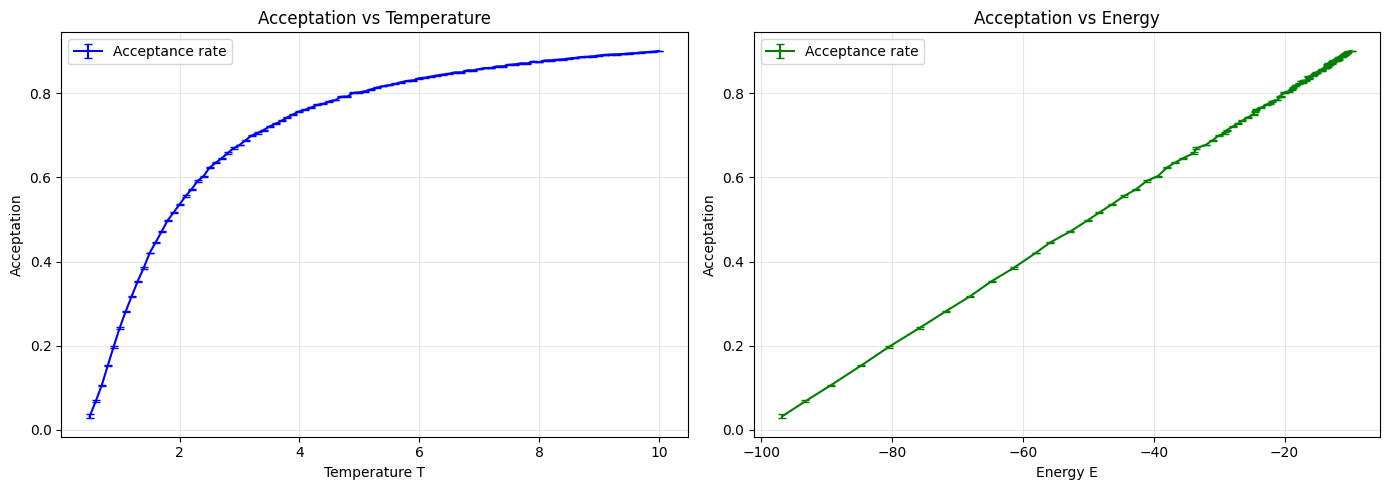

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

acceptation_value = result["Acceptation"]
acceptation_error = result_error["Acceptation"]
energy_value = result["Energy"]

# Acceptation vs T
ax1.errorbar(T, acceptation_value, yerr=acceptation_error, capsize=3,
             color='blue', linestyle='-', label='Acceptance rate')
ax1.set_xlabel('Temperature T')
ax1.set_ylabel("Acceptation")
ax1.set_title("Acceptation vs Temperature")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Acceptation vs E
ax2.errorbar(energy_value, acceptation_value, yerr=acceptation_error, capsize=3,
             color='green', linestyle='-', label='Acceptance rate')
ax2.set_xlabel('Energy E')
ax2.set_ylabel("Acceptation")
ax2.set_title("Acceptation vs Energy")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## Plot Ground state for $T \approx 0$

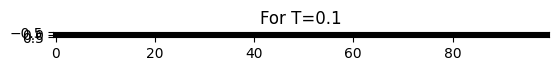

In [13]:
Tj = 0.1
spins, result_temp = simulation(Tj, Nt, N_skip)
plot_chain(spins, Tj)

# Observation

I performed simulations for relatively large system sizes and for a range of temperatures between T = 0.5 and T = 10.

Overall, the numerical results are in very good agreement with the theoretical predictions for most observables over a wide temperature range.

## Physical quantities

Several important observations can be made:

- As T decreases toward zero, discrepancies between numerical and theoretical results become more visible.
  For this reason, I chose to restrict the final analysis to T ≥ 0.5. At lower temperatures (e.g. T ≈ 0.1), fluctuations and numerical limitations make the interpretation of results more difficult, although the qualitative behavior remains consistent.

- Energy:
  The numerical energy ⟨E⟩ matches the theoretical prediction very closely over the entire temperature range.
  Error bars remain small, indicating good convergence and low variance. This is expected since energy is a relatively stable observable in Monte Carlo simulations.

- Magnetization:
  The average magnetization ⟨m⟩ tends toward zero for all T > 0, in agreement with the exact result for the one-dimensional Ising model with zero external field.
  
  However, the error bars increase significantly at low temperature. This reflects large fluctuations between different simulations: the system tends to remain in one of the two ordered states (all spins up or all spins down) for long times, and can occasionally flip randomely.
  
  This behavior is not a true phase transition (since no phase transition exists in 1D at finite temperature), but rather a finite-size effect combined with slow dynamics at low temperature.

- Susceptibility:
  The theoretical susceptibility diverges as T → 0. In contrast, the numerical susceptibility remains finite and increases only moderately.
  
  This discrepancy is expected:
  - finite system size limits fluctuations,
  - insufficient sampling of rare magnetization flips at low temperature,
  - strong autocorrelation effects.
  
  As a result, the Monte Carlo estimate underestimates the true susceptibility in this regime.

- Specific heat:
  The numerical specific heat follows the theoretical curve very well over most of the temperature range.
  Small deviations appear at low temperature, but they are much less significant than for the susceptibility. Error bars remain relatively small.

## Average errors

The average deviations between numerical and theoretical results are:

- Energy average error: 0.0987
- Magnetization average error: 0.0113
- Specific heat average error: 0.00915
- Susceptibility average error: 5.11

The large error for susceptibility confirms that this observable is the most difficult to estimate accurately, especially at low temperature.

## Acceptance rate

The acceptance probability of the Metropolis algorithm shows the following behavior:

- The acceptance rate increases with temperature.
  At high temperature, most proposed spin flips are accepted because thermal fluctuations dominate.

- As temperature decreases, the acceptance rate drops significantly and approaches zero as T → 0.
  This is expected since the system is close to its ground state and most proposed flips increase the energy.

- This implies that the algorithm becomes less efficient at low temperature:
  - dynamics slow down,
  - autocorrelation times increase,
  - longer simulations are required to reach equilibrium.

- A plot of acceptance versus energy shows a globally increasing trend, consistent with the fact that higher-energy configurations allow more energetically favorable transitions.

## Additional remarks

- The absence of a true phase transition at finite temperature is confirmed: all observables evolve smoothly with temperature.

- Finite-size effects play an important role, especially at low temperature:
  - long-lived metastable states,
  - large fluctuations of magnetization,
  - difficulty in sampling the full phase space.

- Proper thermalization is crucial. At low temperature, significantly longer thermalization times are required due to slow dynamics.

- Statistical errors are observable-dependent:
  energy converges quickly, while susceptibility requires much more sampling.


---

# Conclusion

In this project, I implemented a Monte Carlo simulation of the one-dimensional Ising model using the Metropolis algorithm. The numerical results obtained for the energy, magnetization, and specific heat are in very good agreement with the exact theoretical predictions over a wide range of temperatures.

This confirms that the Metropolis Monte Carlo method provides an accurate and robust approach to sample the equilibrium properties of this system. In particular, observables such as the energy and specific heat are well reproduced, with small statistical errors.

Some limitations appear at low temperature, where the dynamics slow down significantly. In this regime, the acceptance rate decreases, autocorrelation times increase, and certain observables, especially the magnetic susceptibility, are more difficult to estimate accurately. These discrepancies are mainly due to finite-size effects and insufficient sampling of rare configurations.

The absence of a phase transition at finite temperature, a key feature of the one-dimensional Ising model, is correctly reproduced by the simulation. All observables vary smoothly with temperature, in agreement with theoretical expectations.

Overall, this study demonstrates that the Metropolis algorithm is well-suited for simulating simple spin systems and provides reliable access to thermodynamic quantities, while also highlighting the importance of proper thermalization, statistical averaging, and finite-size considerations in Monte Carlo simulations.